Connected to .venv (Python 3.11.13)

### This notebook reproduces all the graphs included in our paper

In [4]:
import numpy as np
from typing import List, Dict, Optional, Tuple, Set, Any
import pandas as pd
from pydantic import BaseModel
from ssa.tasks.task import TaskRunner, TaskBase, ProxyAgent, ProxyTask
from copy import deepcopy
from ssa.agents import (
    AgentHistory,
    AgentActionResponse,
    AgentBase,
    MarketInfo,
    StaticAgent,
    LLMAgent,
    OracleAgent,
    AgentLog,
)
from loguru import logger
import asyncio

from ssa.utils import format_dict_str
from ssa.plotting import plot_agent_trace, plot_allocation

from ssa.tasks.cipher import CipherTask
from ssa.market import RoundData, ExperimentLog

import matplotlib.pyplot as plt
import os

from collections import defaultdict

import numpy as np
from ssa.analysis import get_summary_df, compute_trace_means, interp_trace


In [80]:
import seaborn as sns
SNS_RED = sns.color_palette("Set1")[0]
SNS_BLUE = sns.color_palette("Set1")[1]
SNS_GREEN = sns.color_palette("Set1")[2]
SNS_CYAN = sns.color_palette("Set2")[0]
SNS_ORANGE = sns.color_palette("Set2")[1]
SNS_BBLUE = sns.color_palette("Set2")[2]
SNS_BPURPLE = sns.color_palette("Set2")[3]
SNS_YELLOW = sns.color_palette("Set2")[5]
SNS_GREY = sns.color_palette("Set2")[7]

In [7]:
# Baseline experiments
logs = []
for f in os.listdir('logs'):
    if "llm_baseline_full" in f:
        try:
            logs.append((f,ExperimentLog.load(f"logs/{f}")))
        except:
            print(f)
            continue


In [8]:
summary_dfs = [get_summary_df(l, ix) for ix, l in logs]

/Users/chris/ssa/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/chris/ssa/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [499]:
df = pd.concat(summary_dfs)
train_target = df.query('train_target > 0').groupby('atype').train_target.mean()
df['recovery'] = df['recovery'] * 100
df['train_p'] = df['train_p'] * 100
df = df.rename({'reward_normalized': "market_share"}, axis=1)
df['market_share'] = df['market_share'] * 100
df['winrate'] = df['winrate'] * 100
df['rep_max'] *= 5
df['rep_avg'] *= 5
df = df.groupby('atype').mean(numeric_only=True)
df['train_target'] = train_target

df = df.sort_values('rank')
df.to_clipboard()

In [42]:
fmt = {'reward': 1,
 'market_share': 1,
 'rank': 1,
 'winrate': 1,
 'win_prio': 2,
 'recovery': 1,
 'rank_jump': 1,
 'top_base_price': 1,
 'avg_base_price': 1,
 'train_p': 1,
 'train_target': 2,
 'skill_spec': 2,
 'winning_bids': 2,
 'all_bids': 2,
 'rep_avg': 2,
 'rep_max': 1,
 'total_tokens': 1,
 'completion_tokens': 1}

fmter = lambda x: ('{:.' + str(x) +'f}').format


In [ ]:
df

,reward,market_share,rank,winrate,win_prio,recovery,rank_jump,top_base_price,avg_base_price,all_bids,winning_bids,train_p,train_target,skill_sum,skill_max,skill_spec,rep_avg,rep_max,rep_spec,total_tokens,completion_tokens
agent_id,,,,,,,,,,,,,,,,,,,,,
goss,726.919071,14.983232,3.100000,92.589462,2.252711,5.959596,5.400000,8.165162,6.474502,0.557054,0.553491,2.895705,NaN,241.500000,92.600000,0.390038,0.668842,0.920009,0.021447,593717.5,128035.9
glm,649.205290,13.001894,4.100000,55.788621,2.269499,5.252525,5.750000,8.621743,6.695030,0.802622,0.783952,5.636553,NaN,225.200000,88.900000,0.564687,0.612602,0.889421,0.029882,700311.0,135228.7
gpt5,703.007233,14.153182,4.700000,58.874643,1.949215,3.838384,4.800000,8.428094,6.963025,0.755965,0.741299,1.931579,NaN,217.700000,86.700000,0.726669,0.560496,0.871917,0.042051,449834.4,18844.6
qwen,587.000271,12.690514,4.700000,47.126794,2.347083,5.454545,4.500000,8.815170,7.020697,0.887470,0.867047,10.912121,NaN,234.000000,93.600000,0.627247,0.580934,0.918573,0.048390,486874.1,32060.0
goog,493.767331,10.932369,5.300000,52.583800,2.475304,5.757576,5.900000,8.284132,7.072499,0.773621,0.731838,13.023517,NaN,254.800000,89.700000,0.266699,0.671129,0.893962,0.020669,599074.8,127373.6
kimi,442.693898,9.631684,5.300000,50.413914,2.401192,4.848485,4.550000,8.119249,6.771012,0.809592,0.764552,11.990425,NaN,235.100000,92.900000,0.528529,0.620954,0.918148,0.032768,456283.1,25845.9
deepseek,457.576921,9.863032,5.600000,44.552192,2.098264,5.252525,5.600000,6.987123,6.526591,0.801390,0.793653,6.000000,NaN,231.700000,87.500000,0.490706,0.610105,0.884084,0.032518,457636.5,22689.0
FIXPL,374.678775,7.072220,6.111111,33.726872,3.094643,4.713805,5.277778,9.512635,6.992186,0.905556,0.905556,20.777778,NaN,231.777778,94.888889,0.603146,0.563267,0.881723,0.044929,0.0,0.0
GRDPL,283.565955,5.186669,7.222222,21.888296,2.931445,2.020202,6.000000,9.992507,6.996405,0.800000,0.800000,11.111111,NaN,246.666667,78.000000,0.103089,0.666428,0.787487,0.006266,0.0,0.0


In [503]:
print(
    df.to_latex(
        columns=core,
        formatters={k: fmter(f) for k, f in fmt.items()},
        caption="Agent Performance Summary",
        label="tab:agent_performance",
    )
)

\begin{table}
\caption{Agent Performance Summary}
\label{tab:agent_performance}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & reward & market_share & rank & winrate & recovery & train_p & train_target & skill_spec & rep_max \\
atype &  &  &  &  &  &  &  &  &  \\
\midrule
goss & 726.9 & 14.98 & 3.10 & 92.6 & 5.96 & 2.90 & 1.75 & 0.39 & 4.6 \\
glm & 649.2 & 13.00 & 4.10 & 55.8 & 5.25 & 5.64 & 2.12 & 0.56 & 4.4 \\
gpt5 & 703.0 & 14.15 & 4.70 & 58.9 & 3.84 & 1.93 & 1.60 & 0.73 & 4.4 \\
qwen & 587.0 & 12.69 & 4.70 & 47.1 & 5.45 & 10.91 & 1.78 & 0.63 & 4.6 \\
goog & 493.8 & 10.93 & 5.30 & 52.6 & 5.76 & 13.02 & 3.00 & 0.27 & 4.5 \\
kimi & 442.7 & 9.63 & 5.30 & 50.4 & 4.85 & 11.99 & 1.70 & 0.53 & 4.6 \\
deepseek & 457.6 & 9.86 & 5.60 & 44.6 & 5.25 & 6.00 & 2.30 & 0.49 & 4.4 \\
FIXPL & 374.7 & 7.07 & 6.11 & 33.7 & 4.71 & 20.78 & 1.00 & 0.60 & 4.4 \\
GRDPL & 283.6 & 5.19 & 7.22 & 21.9 & 2.02 & 11.11 & 3.67 & 0.10 & 3.9 \\
llama & 212.4 & 3.71 & 8.30 & 18.6 & 2.93 & 0.00 & NaN & 0.66 & 3.9 \\
\bottomru

In [32]:
latex_transposed = df[['market_share', 'rank']].T.to_latex(
    formatters={col: '{:.1f}'.format 
                for col in df.T.columns},
    caption='Agent performance Summary',
    label='tab:agent_performance_abridged'
)
print(latex_transposed)

\begin{table}
\caption{Agent performance Summary}
\label{tab:agent_performance_abridged}
\begin{tabular}{lrrrrrrrrrr}
\toprule
agent_id & goss & glm & gpt5 & qwen & goog & kimi & deepseek & FIXPL & GRDPL & llama \\
\midrule
market_share & 15.0 & 13.0 & 14.2 & 12.7 & 10.9 & 9.6 & 9.9 & 7.1 & 5.2 & 3.7 \\
rank & 3.1 & 4.1 & 4.7 & 4.7 & 5.3 & 5.3 & 5.6 & 6.1 & 7.2 & 8.3 \\
\bottomrule
\end{tabular}
\end{table}



In [4]:
df = pd.concat([pd.DataFrame([dict(run=ix, agent_id=agent.id, reward=agent.total_reward, atype=agent.id.split("-")[0]) for agent in l.agents]) for ix, l in logs])
# Calculate mean reward per agent type per run
df_run_means = (df.groupby(["atype", "run"])
                .mean(numeric_only=True)
                .reset_index())

# Add ranking within each run (1 = best performance)
df_run_means['rank'] = (df_run_means.groupby('run')['reward']
                        .rank(ascending=False, method='average'))

# Calculate summary statistics
results = (df_run_means.groupby("atype")
           .agg({
               'reward': ['mean', 'std'],
               'rank': 'mean'
           })
           .round(2))

results_transposed = results.T

print("Results:")
print(results_transposed)

latex_transposed = results_transposed.to_latex(
    formatters={col: '{:.1f}'.format if 'reward' in col else '{:.2f}'.format 
                for col in results_transposed.columns},
    caption='Agent Performance Summary (Transposed)',
    label='tab:agent_performance_transposed'
)
print(latex_transposed)

Results:
atype         FIXPL   GRDPL  deepseek     glm    goog    goss    gpt5    kimi  \
reward mean  374.68  283.57    457.58  649.21  493.77  726.92  703.01  442.69   
       std   316.14  334.14    343.12  397.36  371.60  384.84  565.98  298.35   
rank   mean    6.11    7.22      5.60    4.10    5.30    3.10    4.70    5.30   

atype         llama    qwen  
reward mean  212.45  587.00  
       std   361.25  505.86  
rank   mean    8.30    4.70  
\begin{table}
\caption{Agent Performance Summary (Transposed)}
\label{tab:agent_performance_transposed}
\begin{tabular}{llrrrrrrrrrr}
\toprule
 & atype & FIXPL & GRDPL & deepseek & glm & goog & goss & gpt5 & kimi & llama & qwen \\
\midrule
\multirow[t]{2}{*}{reward} & mean & 374.68 & 283.57 & 457.58 & 649.21 & 493.77 & 726.92 & 703.01 & 442.69 & 212.45 & 587.00 \\
 & std & 316.14 & 334.14 & 343.12 & 397.36 & 371.60 & 384.84 & 565.98 & 298.35 & 361.25 & 505.86 \\
\cline{1-12}
rank & mean & 6.11 & 7.22 & 5.60 & 4.10 & 5.30 & 3.10 & 4.70 & 5.3

In [ ]:
def gini(wealth):
    wealth = np.sort(wealth[wealth >= 0])
    n = len(wealth)
    cumsum = np.cumsum(wealth)
    return 1 - (2 * np.sum(cumsum)) / (n * cumsum[-1]) + 1 / n


In [33]:
from scipy.stats import pearsonr, spearmanr

_gini = df.apply(gini, axis=1)

In [41]:
tdf = pd.concat(trace_dfs)

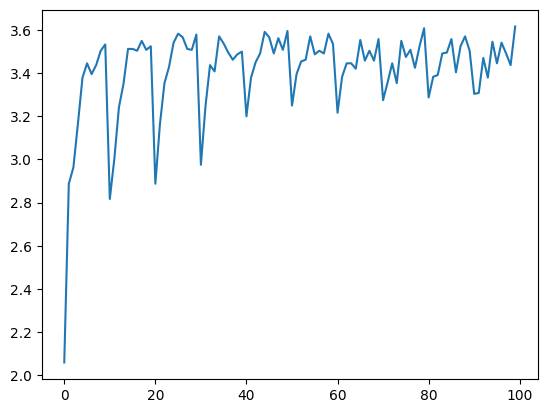

In [51]:
plt.plot(tdf.groupby('step').mean(numeric_only=True)['metacog'])

(100,)

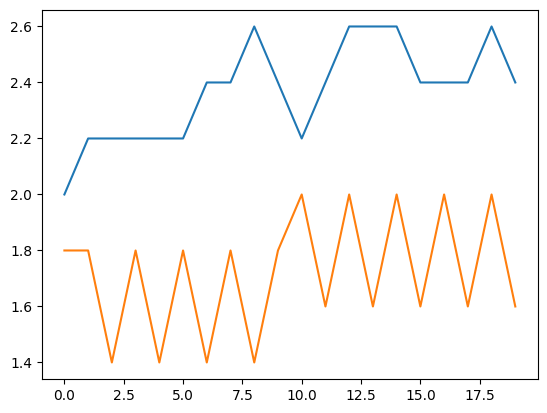

In [78]:
__df = tdf.groupby(['agent_id', 'step']).mean(numeric_only=True)['metacog']

plt.plot(__df.loc['gpt5'].to_numpy().reshape((5, -1)).mean(axis=0))
plt.plot(__df.loc['llama'].to_numpy().reshape((5, -1)).mean(axis=0))



In [50]:
tdf

0        0
1        1
2        2
3        3
4        4
        ..
2395    95
2396    96
2397    97
2398    98
2399    99
Name: step, Length: 23999, dtype: int64

In [39]:
spearmanr(_gini, tdf['metacog'])

SignificanceResult(statistic=np.float64(0.1515151515151515), pvalue=np.float64(0.6760651759978538))

## Price Analysis (Open v.s. Sealed Bids)

In [114]:
price_logs = []
non_price_logs = []
for f in os.listdir('logs'):
    if "llm_baseline_full_p" in f and "price" in f: 
        price_logs.append(ExperimentLog.load(f"logs/{f}"))
    if "llm_baseline_full_p" in f and "price" not in f: 
        non_price_logs.append(ExperimentLog.load(f"logs/{f}"))

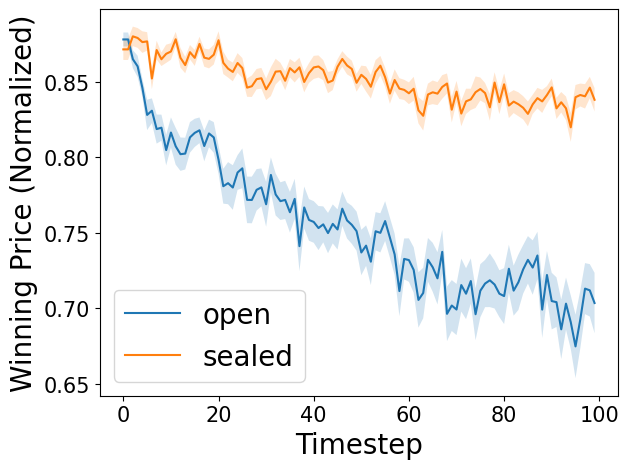

In [116]:
non_traces = []

for l in non_price_logs:
    for j in l.job_ids:
        t = compute_trace_means(l.agent_bids_normalized[j])
        non_traces.append(interp_trace(t))
price_traces = []

for l in price_logs:
    for j in l.job_ids:
        t = compute_trace_means(l.agent_bids_normalized[j])
        price_traces.append(interp_trace(t))

plt.plot()

psem = np.array(price_traces).std(axis=0) / np.sqrt(len(price_traces))
pmean = np.mean(price_traces, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, alpha=0.2)
plt.plot(np.arange(100), np.mean(price_traces, axis=0), label='open')


psem = np.array(non_traces).std(axis=0) / np.sqrt(len(non_traces))
pmean = np.mean(non_traces, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, alpha=0.2)
plt.plot(np.arange(100), np.mean(non_traces, axis=0), label='sealed')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Winning Price (Normalized)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()


In [160]:
price_skill

[array([0. , 0.1, 0. , 0.1, 0.1, 0. , 0. , 0. , 0. , 0. , 0.1, 0.2, 0. ,
        0. , 0. , 0. , 0.1, 0. , 0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. ,
        0.1, 0.1, 0.1, 0.2, 0. , 0. , 0. , 0.1, 0.1, 0. , 0. , 0. , 0. ,
        0. , 0. , 0.2, 0.2, 0.3, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.2,
        0. , 0. , 0.1, 0.3, 0.3, 0.2, 0. , 0.1, 0.2, 0.1, 0.1, 0. , 0.1,
        0. , 0.1, 0. , 0.1, 0.1, 0.1, 0.2, 0.1, 0.2, 0. , 0. , 0. , 0. ,
        0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. , 0. ]),
 array([0. , 0.2, 0.1, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.2, 0. ,
        0. , 0. , 0. , 0.1, 0. , 0.1, 0. , 0.1, 0.1, 0.1, 0.1, 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0.1, 0.2, 0.2, 0.2, 0.2, 0.1, 0. , 0. ,
        0. , 0. , 0.1, 0.1, 0.1, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0.1, 0.1, 0.1, 0. , 0. , 0. , 0.1, 0. , 0

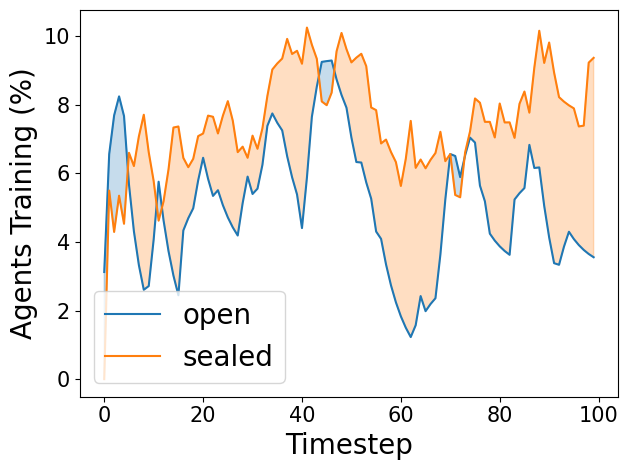

In [161]:
price_skill = []
for experiment in price_logs:
    price_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions[:-2]]) for hx in experiment.history]))
period = 10
n_agents = 8

non_price_skill = []
for experiment in non_price_logs:
    non_price_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions[:-2]]) for hx in experiment.history]))

prc = pd.Series(np.mean(price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc =  pd.Series(np.mean(non_price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

plt.plot(prc, label='open')
plt.plot(noprc, label='sealed')

plt.fill_between(
    np.arange(100),prc, noprc, where=(prc > noprc), 
    interpolate=True, color="tab:blue", alpha=0.25, 
)

plt.fill_between(
    np.arange(100),prc, noprc, where=(noprc > prc), 
    interpolate=True, color="tab:orange", alpha=0.25,
)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()

In [118]:
partial = [ExperimentLog.load(f'logs/moral/partial_{i}.log') for i in range(4)]
full = [ExperimentLog.load(f'logs/moral/full_{i}.log') for i in range(4)]

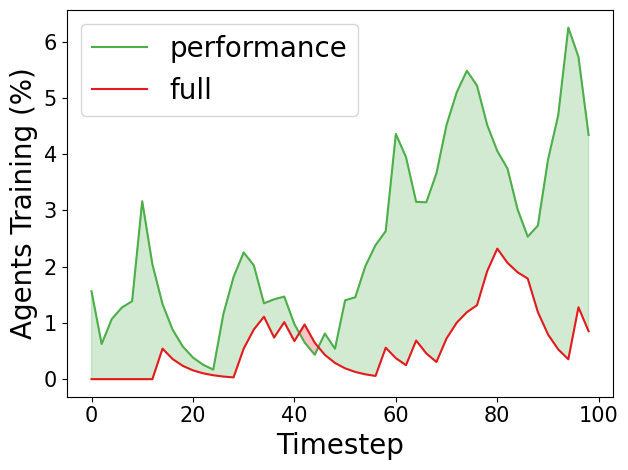

In [167]:
partial_skill = []
for experiment in partial:
    partial_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions]) for hx in experiment.history]))

full_skill = []
for experiment in full:
    full_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions])   for hx in experiment.history]))

_p = 2
partial_skill = np.array(partial_skill).reshape((4, _p, -1)).mean(axis=1)
full_skill = np.array(full_skill).reshape((4, _p, -1)).mean(axis=1)

period = 5
prc = pd.Series(np.mean(partial_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc =  pd.Series(np.mean(full_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

plt.plot(np.arange(0, 100, _p), prc, color=SNS_GREEN, label='performance')
plt.plot(np.arange(0, 100, _p), noprc, color=SNS_RED, label='full')
plt.fill_between(
    np.arange(0, 100, _p),prc, noprc, where=(prc > noprc), 
    interpolate=True, color=SNS_GREEN, alpha=0.25, 
)

plt.fill_between(
    np.arange(0, 100, _p),prc, noprc, where=(noprc > prc), 
    interpolate=True, color=SNS_RED, alpha=0.25,
)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()

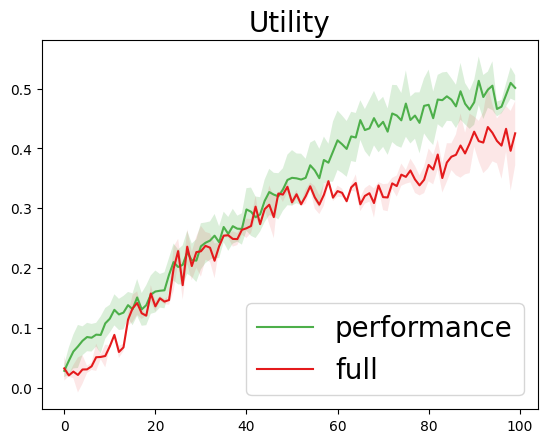

In [120]:
from ssa.analysis import get_utility

# %%
partial_u = [np.array([get_utility(hx) for hx in experiment.history]) for experiment in partial]
full_u = [np.array([get_utility(hx) for hx in experiment.history]) for experiment in full]

psem = np.array(partial_u).std(axis=0) / np.sqrt(len(partial_u))
pmean = np.mean(partial_u, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, alpha=0.2, color=SNS_GREEN, edgecolor='none')

psem = np.array(full_u).std(axis=0) / np.sqrt(len(full_u))
pmean = np.mean(full_u, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, color=SNS_RED, alpha=0.1, edgecolor='none')

plt.plot(np.mean(partial_u, axis=0), label='performance', color=SNS_GREEN)
plt.plot(np.mean(full_u, axis=0), label='full', color=SNS_RED)
plt.title('Utility', fontsize=20)
plt.legend(fontsize=20)

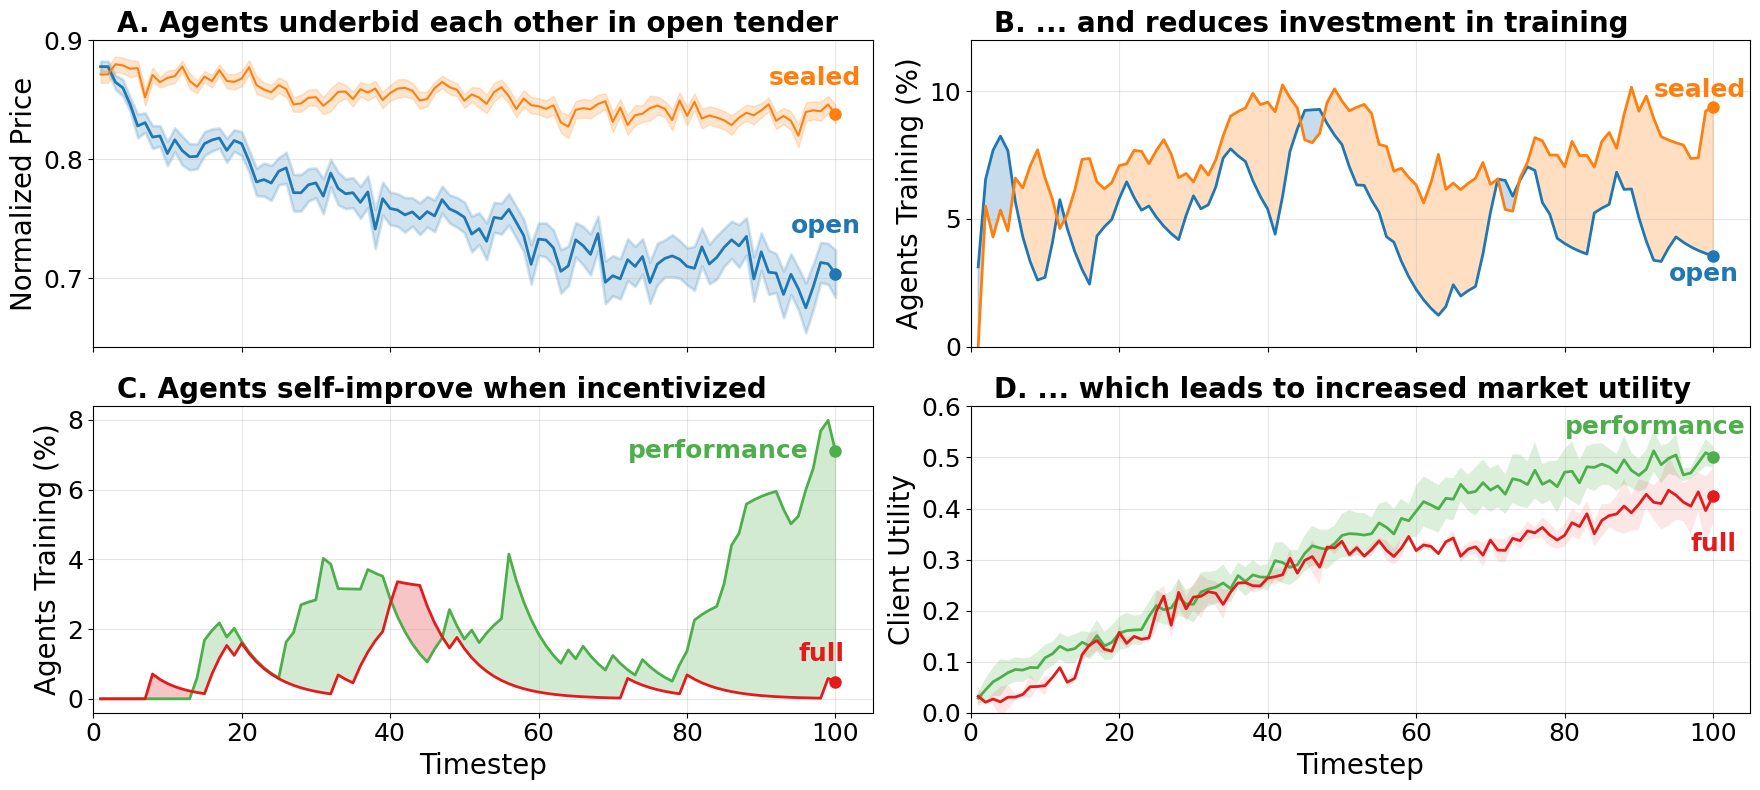

In [213]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# First subplot - Winning Price
psem = np.array(price_traces).std(axis=0) / np.sqrt(len(price_traces))
pmean = np.mean(price_traces, axis=0)

ax1.fill_between(np.arange(1, 101), pmean - psem, pmean + psem, alpha=0.2, color='tab:blue', linewidth=2)
ax1.plot(np.arange(1, 101), pmean, markevery=[-1], marker='o', markersize=8, color='tab:blue', linewidth=2)

psem = np.array(non_traces).std(axis=0) / np.sqrt(len(non_traces))
pmean_non = np.mean(non_traces, axis=0)

ax1.fill_between(np.arange(1, 101), pmean_non - psem, pmean_non + psem, alpha=0.2, color='tab:orange')
ax1.plot(np.arange(1, 101), pmean_non, markevery=[-1], marker='o', markersize=8, color='tab:orange')

ax1.set_ylabel("Normalized Price", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 105)  # Extend to accommodate legend text

# Position legend text near end points
ax1.text(94, pmean[-1] + 0.04, 'open', fontsize=18, va='center', color='tab:blue', weight='bold')
ax1.text(91, pmean_non[-1] + 0.03, 'sealed', fontsize=18, va='center', color='tab:orange', weight='bold')
ax1.set_yticks([0.7, 0.8, 0.9])

# Second subplot - Agent Training
prc = pd.Series(np.mean(price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc = pd.Series(np.mean(non_price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

ax2.plot(np.arange(1, 101), prc, markevery=[-1], marker='o', markersize=8, color='tab:blue', linewidth=2)
ax2.plot(np.arange(1, 101), noprc, markevery=[-1], marker='o', markersize=8, color='tab:orange', linewidth=2)

ax2.fill_between(
    np.arange(1, 101), prc, noprc, where=(prc > noprc), 
    interpolate=True, color="tab:blue", alpha=0.25, 
)

ax2.fill_between(
    np.arange(1, 101), prc, noprc, where=(noprc > prc), 
    interpolate=True, color="tab:orange", alpha=0.25,
)

ax2.set_ylabel("Agents Training (%)", fontsize=20)
ax2.set_yticks([0, 5, 10])
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 105)  # Extend to accommodate legend text
ax2.set_ylim(0, 12)

# Position legend text near end points
ax2.text(94, prc[-1]-0.7, 'open', fontsize=18, va='center', color='tab:blue', weight='bold')
ax2.text(92, noprc[-1]+0.7, 'sealed', fontsize=18, va='center', color='tab:orange', weight='bold')

###########################################
partial_skill = []
for experiment in partial:
    partial_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions]) for hx in experiment.history]))

full_skill = []
for experiment in full:
    full_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions])   for hx in experiment.history]))

_p = 1
partial_skill = np.array(partial_skill).reshape((4, _p, -1)).mean(axis=1)
full_skill = np.array(full_skill).reshape((4, _p, -1)).mean(axis=1)

period = 10
prc = pd.Series(np.mean(partial_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc =  pd.Series(np.mean(full_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

ax3.plot(np.arange(1, 101, _p), prc, markevery=[-1], marker='o', markersize=8, color=SNS_GREEN, label='performance', linewidth=2)
ax3.plot(np.arange(1, 101, _p), noprc, markevery=[-1], marker='o', markersize=8, color=SNS_RED, label='full', linewidth=2)
ax3.fill_between(
    np.arange(1, 101, _p),prc, noprc, where=(prc > noprc), 
    interpolate=True, color=SNS_GREEN, alpha=0.25, 
)

ax3.fill_between(
    np.arange(1, 101, _p),prc, noprc, where=(noprc > prc), 
    interpolate=True, color=SNS_RED, alpha=0.25,
)
ax3.tick_params(axis='both', which='major', labelsize=18)
ax3.set_ylabel("Agents Training (%)", fontsize=20)
ax3.set_xlabel("Timestep", fontsize=20)
ax3.grid(True, alpha=0.3)
# Position legend text near end points

ax3.text(72, prc[-1], 'performance', fontsize=18, va='center', color=SNS_GREEN, weight='bold')
ax3.text(95, noprc[-1]+0.8, 'full', fontsize=18, va='center', color=SNS_RED, weight='bold')


partial_u = [np.array([get_utility(hx) for hx in experiment.history]) for experiment in partial]
full_u = [np.array([get_utility(hx) for hx in experiment.history]) for experiment in [full[0], full[3]]]

psem = np.array(partial_u).std(axis=0) / np.sqrt(len(partial_u))
pmean = np.mean(partial_u, axis=0)

ax4.fill_between(np.arange(1, 101),pmean - psem, pmean + psem, alpha=0.2, color=SNS_GREEN, edgecolor='none')

psem = np.array(full_u).std(axis=0) / np.sqrt(len(full_u))
pmean = np.mean(full_u, axis=0)

ax4.fill_between(np.arange(1, 101),pmean - psem, pmean + psem, color=SNS_RED, alpha=0.1, edgecolor='none')

ax4.plot(np.arange(1, 101), np.mean(partial_u, axis=0), markevery=[-1], marker='o', markersize=8,label='performance', linewidth=2, color=SNS_GREEN)
ax4.plot(np.arange(1, 101), np.mean(full_u, axis=0), markevery=[-1], marker='o', markersize=8, label='full', linewidth=2, color=SNS_RED)
ax4.set_ylabel('Client Utility', fontsize=20)
ax4.tick_params(axis='both', which='major', labelsize=18)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 0.6)
ax4.set_xlabel("Timestep", fontsize=20)

# Position legend text near end points
ax4.text(80, 0.56, 'performance', fontsize=18, va='center', color=SNS_GREEN, weight='bold')
ax4.text(97, 0.33, 'full', fontsize=18, va='center', color=SNS_RED, weight='bold')

ax1.set_title("A. Agents underbid each other in open tender", fontsize=20, weight='bold', ha='left', x=0.03)
ax2.set_title("B. ... and reduces investment in training", fontsize=20, weight='bold', ha='left', x=0.03)
ax3.set_title("C. Agents self-improve when incentivized", fontsize=20, weight='bold', ha='left', x=0.03)
ax4.set_title("D. ... which leads to increased market utility", fontsize=20, weight='bold', ha='left', x=0.03)


# %%
plt.tight_layout()
plt.show()



# LLM v.s. SSA

In [2]:
ssa_logs = []
for fp in os.listdir('logs'):
    if 'ssa' in fp:
        try:
            ssa_logs.append((fp, ExperimentLog.load(f'logs/{fp}')))
        except Exception as e:
            print(e, fp)

1 validation error for ExperimentLog
  Invalid JSON: control character (\u0000-\u001F) found while parsing a string at line 1 column 33554433 [type=json_invalid, input_value='{"config":{"market_limit...x00\x00\x00\x00\x00\x00', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/json_invalid l2m_ssa_0.log


In [67]:
core = ['reward', 'market_share', 'rank', 'winrate', 'recovery', 'train_target', 'train_p', 'skill_spec', 'rep_max']
all = ['reward', 'market_share', 'rank', 'winrate', 'win_prio', 'recovery', 'rank_jump', 'top_base_price', 'avg_base_price', 'train_p', 'train_target', 'skill_spec', 'winning_bids', 'all_bids', 'rep_avg', 'rep_max', 'total_tokens', 'completion_tokens']

In [59]:
ssa_df = pd.concat([get_summary_df(l, ix) for ix, l in ssa_logs])
train_target = ssa_df.query('train_target > 0').groupby('atype').train_target.mean()
ssa_df['recovery'] = ssa_df['recovery'] * 100
ssa_df['train_p'] = ssa_df['train_p'] * 100
ssa_df = ssa_df.rename({'reward_normalized': "market_share"}, axis=1)
ssa_df['market_share'] = ssa_df['market_share'] * 100
ssa_df['winrate'] = ssa_df['winrate'] * 100
ssa_df['rep_max'] *= 5
ssa_df['rep_avg'] *= 5
ssa_df = ssa_df.groupby('atype').mean(numeric_only=True)
ssa_df['train_target'] = train_target

ssa_df

,reward,market_share,rank,winrate,win_prio,recovery,rank_jump,top_base_price,avg_base_price,all_bids,winning_bids,train_p,train_target,skill_sum,skill_max,skill_spec,rep_avg,rep_max,rep_spec,total_tokens,completion_tokens
atype,,,,,,,,,,,,,,,,,,,,,
FIXPL,351.664606,6.628493,7.111111,27.925187,3.833005,3.815937,4.722222,9.568891,7.018313,0.900000,0.900000,21.444444,1.000000,248.888889,94.666667,0.467539,3.002551,4.354432,0.041191,0.000000,0.000000
GRDPL,173.902121,3.156710,8.444444,14.049471,3.028067,2.805836,6.444444,10.000000,7.007751,0.800000,0.800000,10.555556,3.666667,254.222222,78.222222,0.077733,3.364794,3.879685,0.005720,0.000000,0.000000
L2M,536.828224,9.339442,5.937500,45.667486,2.654845,3.409091,3.500000,8.839367,7.047021,0.884919,0.874516,9.250000,1.200000,222.062500,91.750000,0.705839,2.788075,4.507735,0.048485,622483.000000,23666.562500
LLM,419.398098,9.701093,5.384615,44.318366,2.232943,4.972805,5.333333,8.136149,6.658311,0.798076,0.770471,13.871795,1.451613,221.769231,94.410256,0.649658,2.968534,4.558874,0.045622,546800.358974,24930.820513
SSA,633.489279,14.257445,4.272727,59.473519,2.057026,5.491276,4.727273,7.678520,6.488271,0.830883,0.815663,7.109091,1.025641,215.218182,93.745455,0.780409,2.828010,4.656364,0.054532,511697.745455,40746.290909


In [502]:
len(ssa_logs)

14

In [501]:
ssa_df = pd.concat([get_summary_df(l, ix) for ix, l in ssa_logs])
train_target = ssa_df.query('train_target > 0').groupby('atype').train_target.mean()
ssa_df = ssa_df.groupby('atype').mean(numeric_only=True)
ssa_df['train_target'] = train_target
ssa_df['recovery'] = ssa_df['recovery'] * 100
ssa_df['train_p'] = ssa_df['train_p'] * 100
ssa_df = ssa_df.rename({'reward_normalized': "market_share"}, axis=1)
ssa_df['market_share'] = ssa_df['market_share'] * 100
ssa_df['winrate'] = ssa_df['winrate'] * 100
ssa_df['rep_max'] *= 5
ssa_df['rep_avg'] *= 5
ssa_df.to_clipboard()

In [35]:
pd.set_option('display.max_columns', None)
ssa_df.apply(lambda x: round(x, 2))

,reward,market_share,rank,winrate,win_prio,recovery,rank_jump,top_base_price,avg_base_price,all_bids,winning_bids,train_p,train_target,skill_sum,skill_max,skill_spec,rep_avg,rep_max,rep_spec,total_tokens,completion_tokens
atype,,,,,,,,,,,,,,,,,,,,,
FIXPL,351.66,6.63,7.11,27.93,3.83,3.82,4.72,9.57,7.02,0.90,0.90,21.44,1.00,248.89,94.67,0.47,0.60,0.87,0.04,0.00,0.00
GRDPL,173.90,3.16,8.44,14.05,3.03,2.81,6.44,10.00,7.01,0.80,0.80,10.56,3.67,254.22,78.22,0.08,0.67,0.78,0.01,0.00,0.00
L2M,536.83,9.34,5.94,45.67,2.65,3.41,3.50,8.84,7.05,0.88,0.87,9.25,1.20,222.06,91.75,0.71,0.56,0.90,0.05,622483.00,23666.56
LLM,419.40,9.70,5.38,44.32,2.23,4.97,5.33,8.14,6.66,0.80,0.77,13.87,1.45,221.77,94.41,0.65,0.59,0.91,0.05,546800.36,24930.82
SSA,633.49,14.26,4.27,59.47,2.06,5.49,4.73,7.68,6.49,0.83,0.82,7.11,1.03,215.22,93.75,0.78,0.57,0.93,0.05,511697.75,40746.29


In [44]:
ssa_df

,reward,market_share,rank,winrate,win_prio,recovery,rank_jump,top_base_price,avg_base_price,all_bids,winning_bids,train_p,train_target,skill_sum,skill_max,skill_spec,rep_avg,rep_max,rep_spec,total_tokens,completion_tokens
atype,,,,,,,,,,,,,,,,,,,,,
FIXPL,351.664606,6.628493,7.111111,27.925187,3.833005,3.815937,4.722222,9.568891,7.018313,0.900000,0.900000,21.444444,1.000000,248.888889,94.666667,0.467539,3.002551,4.354432,0.041191,0.000000,0.000000
GRDPL,173.902121,3.156710,8.444444,14.049471,3.028067,2.805836,6.444444,10.000000,7.007751,0.800000,0.800000,10.555556,3.666667,254.222222,78.222222,0.077733,3.364794,3.879685,0.005720,0.000000,0.000000
L2M,536.828224,9.339442,5.937500,45.667486,2.654845,3.409091,3.500000,8.839367,7.047021,0.884919,0.874516,9.250000,1.200000,222.062500,91.750000,0.705839,2.788075,4.507735,0.048485,622483.000000,23666.562500
LLM,419.398098,9.701093,5.384615,44.318366,2.232943,4.972805,5.333333,8.136149,6.658311,0.798076,0.770471,13.871795,1.451613,221.769231,94.410256,0.649658,2.968534,4.558874,0.045622,546800.358974,24930.820513
SSA,633.489279,14.257445,4.272727,59.473519,2.057026,5.491276,4.727273,7.678520,6.488271,0.830883,0.815663,7.109091,1.025641,215.218182,93.745455,0.780409,2.828010,4.656364,0.054532,511697.745455,40746.290909


In [79]:
fmt = {'reward': 1,
 'market_share': 2,
 'rank': 2,
 'winrate': 1,
 'win_prio': 2,
 'recovery': 2,
 'rank_jump': 2,
 'top_base_price': 1,
 'avg_base_price': 1,
 'train_p': 2,
 'train_target': 2,
 'skill_spec': 2,
 'winning_bids': 2,
 'all_bids': 2,
 'rep_avg': 2,
 'rep_max': 1,
 'total_tokens': 1,
 'completion_tokens': 1}

fmter = lambda x: ('{:.' + str(x) +'f}').format

print(
    ssa_df.to_latex(
        columns=core,
        formatters={k: fmter(f) for k, f in fmt.items()},
        caption="SSA Performance Summary",
        label="tab:ssa_performance",
    )
)

\begin{table}
\caption{SSA Performance Summary}
\label{tab:ssa_performance}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & reward & market_share & rank & winrate & recovery & train_p & train_target & skill_spec & rep_max \\
atype &  &  &  &  &  &  &  &  &  \\
\midrule
FIXPL & 351.7 & 6.63 & 7.11 & 27.9 & 3.82 & 21.44 & 1.00 & 0.47 & 4.4 \\
GRDPL & 173.9 & 3.16 & 8.44 & 14.0 & 2.81 & 10.56 & 3.67 & 0.08 & 3.9 \\
L2M & 536.8 & 9.34 & 5.94 & 45.7 & 3.41 & 9.25 & 1.20 & 0.71 & 4.5 \\
LLM & 419.4 & 9.70 & 5.38 & 44.3 & 4.97 & 13.87 & 1.45 & 0.65 & 4.6 \\
SSA & 633.5 & 14.26 & 4.27 & 59.5 & 5.49 & 7.11 & 1.03 & 0.78 & 4.7 \\
\bottomrule
\end{tabular}
\end{table}



In [75]:
ssa_df = pd.concat([get_summary_df(l, ix) for ix, l in ssa_logs])
ssa_df = pd.concat([get_summary_df(l, ix) for ix, l in ssa_logs])
ssa_df['recovery'] = ssa_df['recovery'] * 100
ssa_df['train_p'] = ssa_df['train_p'] * 100
ssa_df = ssa_df.rename({'reward_normalized': "market_share"}, axis=1)
ssa_df['market_share'] = ssa_df['market_share'] * 100
ssa_df['winrate'] = ssa_df['winrate'] * 100
ssa_df['rep_max'] *= 5
ssa_df['rep_avg'] *= 5
train_target = ssa_df.query('train_target > 0').groupby('atype').agg(
    {'train_target': lambda x: f"{round(x.mean(), fmt['train_target'])} $\pm$ {round(x.std(), fmt['train_target'])}"}
)

ssa_df = ssa_df.groupby('atype').agg(
    {f: lambda x: f"{round(x.mean(), fmt[f])} $\pm$ {round(x.std(), fmt[f])}" for f in core}
)
ssa_df['train_target'] = train_target
print(ssa_df[core].to_latex( caption="SSA Performance Summary",
        label="tab:ssa_performance",))

\begin{table}
\caption{SSA Performance Summary}
\label{tab:ssa_performance}
\begin{tabular}{llllllllll}
\toprule
 & reward & market_share & rank & winrate & recovery & train_target & train_p & skill_spec & rep_max \\
atype &  &  &  &  &  &  &  &  &  \\
\midrule
FIXPL & 351.7 $\pm$ 418.6 & 6.6 $\pm$ 8.2 & 7.1 $\pm$ 3.6 & 27.9 $\pm$ 29.0 & 3.8 $\pm$ 3.4 & 1.0 $\pm$ 0.0 & 21.4 $\pm$ 4.7 & 0.5 $\pm$ 0.2 & 4.4 $\pm$ 0.3 \\
GRDPL & 173.9 $\pm$ 150.4 & 3.2 $\pm$ 2.7 & 8.4 $\pm$ 1.4 & 14.0 $\pm$ 9.9 & 2.8 $\pm$ 2.3 & 3.67 $\pm$ 0.5 & 10.6 $\pm$ 2.2 & 0.1 $\pm$ 0.0 & 3.9 $\pm$ 0.3 \\
L2M & 536.8 $\pm$ 500.1 & 9.3 $\pm$ 8.7 & 5.9 $\pm$ 3.4 & 45.7 $\pm$ 37.0 & 3.4 $\pm$ 2.4 & 1.2 $\pm$ 0.42 & 9.2 $\pm$ 14.1 & 0.7 $\pm$ 0.2 & 4.5 $\pm$ 0.3 \\
LLM & 419.4 $\pm$ 331.0 & 9.7 $\pm$ 8.3 & 5.4 $\pm$ 2.6 & 44.3 $\pm$ 25.7 & 5.0 $\pm$ 3.0 & 1.45 $\pm$ 0.57 & 13.9 $\pm$ 16.0 & 0.6 $\pm$ 0.3 & 4.6 $\pm$ 0.3 \\
SSA & 633.5 $\pm$ 382.3 & 14.3 $\pm$ 10.4 & 4.3 $\pm$ 2.5 & 59.5 $\pm$ 26.1 & 5.5 $\pm$ 2.9 & 1.03

In [ ]:
# Analysis on changing price sensitivity
price_points = []
actions = []
for i in range(4):
    filepath = f'logs/wq/wq_exp_{i}.log'
    exp_log = ExperimentLog.load(filepath)

    for j in exp_log.job_ids:
        for agent_id, pp in zip(exp_log.agent_ids, exp_log.agent_bids_normalized[j]):
            job_type = j[3]
            for p in pp:
                tp, p = p
                price_points.append(dict(agent_id=agent_id, agent_type=agent_id[:3], task=job_type, step=tp, price=p))
    
    actions.append([[action.targets for action in hx.agent_actions if action.action == 'train'] for hx in exp_log.history])
    # price_traces.append(interp_trace(t))

In [ ]:
df = pd.DataFrame(price_points)
df.groupby(['task', 'agent_type']).mean(numeric_only=True)

step     price
task agent_type                     
A    L2M         43.416667  0.787491
     SSA         48.532249  0.741800
B    L2M         47.458295  0.816184
     SSA         42.179185  0.728643
C    L2M         45.955801  0.853457
     SSA         47.222222  0.717297
D    L2M         46.227610  0.895510
     SSA         45.232444  0.825234

In [ ]:
skill_counts = []
for a in actions:
    for _a in a:
        for __a in _a:
            skill_counts.append(__a[0][0])

from collections import Counter

Counter(skill_counts)

Counter({'SK-C': 178, 'SK-D': 156, 'SK-B': 99, 'SK-A': 86})

In [ ]:
filepath = 'logs/market_recession_ssa2_3.log'
exp_log = ExperimentLog.load(filepath)

In [ ]:
ssa_skill = []
ssa_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions]) for hx in exp_log.history]))

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Timestep', ylabel='Agents performing training (%)'>)

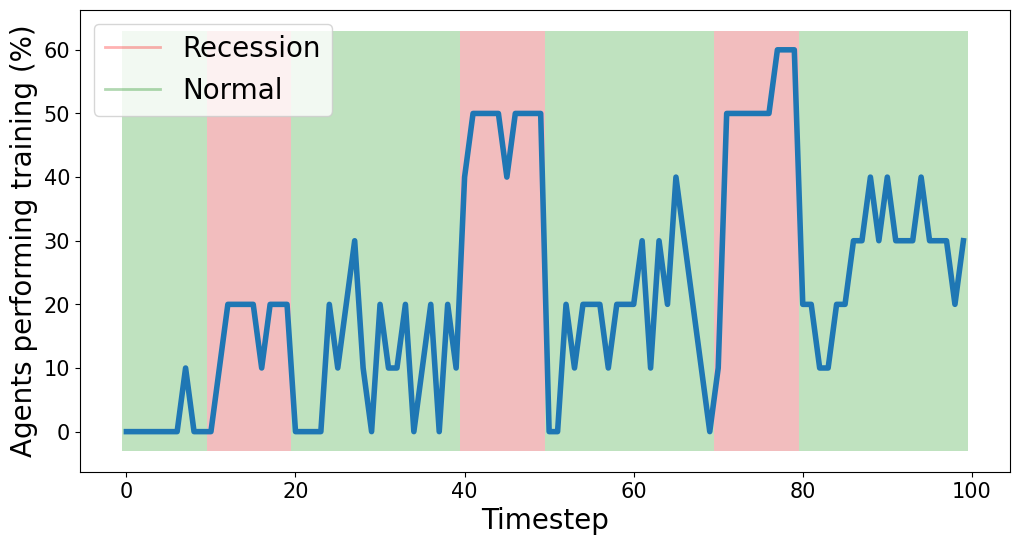

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_bool_regions_with_line(bool_array, float_array, x=None):
    if x is None:
        x = np.arange(len(bool_array))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot line first to get proper y-limits
    ax.plot(x, float_array, color='tab:blue', linewidth=4, zorder=3)
    ymin, ymax = ax.get_ylim()
    
    # Create rectangles for each boolean value
    for i, is_true in enumerate(bool_array):
        color = 'tab:red' if is_true else 'tab:green'
        rect = patches.Rectangle((i-0.5, ymin), 1, ymax-ymin, facecolor=color, alpha=0.3, zorder=1)
        ax.add_patch(rect)
    
    # Add legend manually (since rectangles don't auto-legend well)
    ax.plot([], [], color='red', alpha=0.3, linewidth=2, label='Recession')
    ax.plot([], [], color='green', alpha=0.3, linewidth=2, label='Normal')
    
    ax.set_xlabel('Timestep', fontsize=20)
    ax.set_ylabel('Agents performing training (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)

    ax.legend(fontsize=20)

    return fig, ax

recession = [True if (round_ix // 10) % 3 == 1 else False for round_ix in range(100)]

plot_bool_regions_with_line(np.array(recession), ssa_skill[0] * 10)

In [ ]:
# Analysis on changing market conditions
filepath = 'logs/market_change_0.log'
exp_log = ExperimentLog.load(filepath)

In [ ]:
agent_rewards = np.array([h.agent_round_rewards for h in experiment.history])

plt.plot(np.cumsum(agent_rewards, axis=0), label=experiment.agent_ids)
plt.legend()

NameError: name 'experiment' is not defined

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Timestep', ylabel='Agents performing training (%)'>)

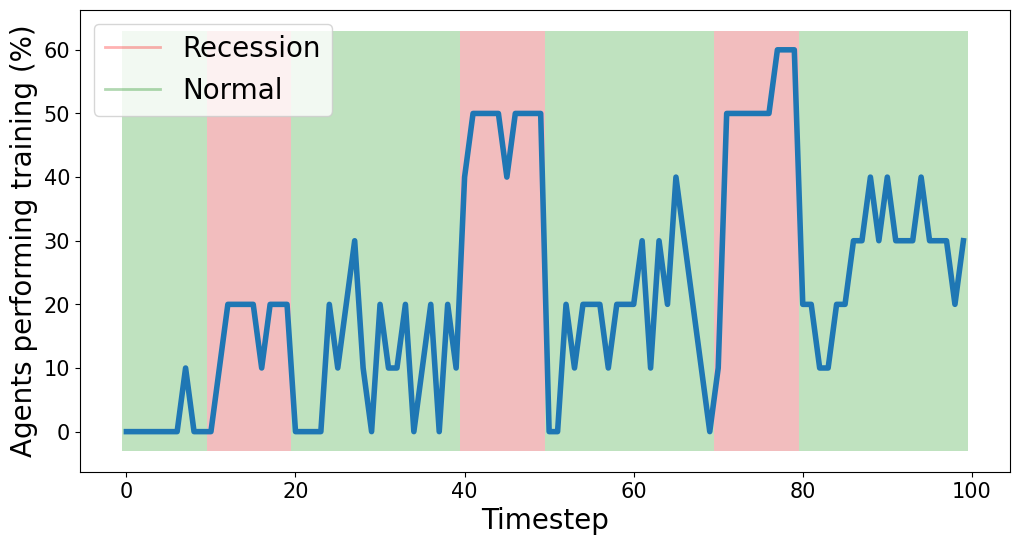

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_bool_regions_with_line(bool_array, float_array, x=None):
    if x is None:
        x = np.arange(len(bool_array))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot line first to get proper y-limits
    ax.plot(x, float_array, color='tab:blue', linewidth=4, zorder=3)
    ymin, ymax = ax.get_ylim()
    
    # Create rectangles for each boolean value
    for i, is_true in enumerate(bool_array):
        color = 'tab:red' if is_true else 'tab:green'
        rect = patches.Rectangle((i-0.5, ymin), 1, ymax-ymin, facecolor=color, alpha=0.3, zorder=1)
        ax.add_patch(rect)
    
    # Add legend manually (since rectangles don't auto-legend well)
    ax.plot([], [], color='red', alpha=0.3, linewidth=2, label='Recession')
    ax.plot([], [], color='green', alpha=0.3, linewidth=2, label='Normal')
    
    ax.set_xlabel('Timestep', fontsize=20)
    ax.set_ylabel('Agents performing training (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)

    ax.legend(fontsize=20)

    return fig, ax

recession = [True if (round_ix // 10) % 3 == 1 else False for round_ix in range(100)]

plot_bool_regions_with_line(np.array(recession), ssa_skill[0] * 10)

In [11]:
agent_action_series = []
price_point_series = []
for wq in [0.1, 0.3, 0.5, 0.7, 0.9, '0.3b']:
    filepath = f'logs/wq/wq_{wq}.log'
    exp_log = ExperimentLog.load(filepath)
    
    if wq == '0.3b': 
        wq = 0.3
    for agent in exp_log.agents:
        for hx in agent.agent_history:
            ix = hx.round
            agent_action = hx.agent_action
            if agent_action.action == 'train':
                a = 1
            else:
                a = 0
            agent_action_series.append([wq, ix, agent.id, a])

    for hx in exp_log.history:
        for job_id, p in hx.winning_prices.items():
            price_point_series.append((wq, hx.round, p / hx.base_prices[job_id])) 

In [ ]:
adf = pd.DataFrame(agent_action_series, columns=['wq', 'round', 'agent_id', 'action'])

Text(0.5, 0, 'Agent likelihood to train (%)')

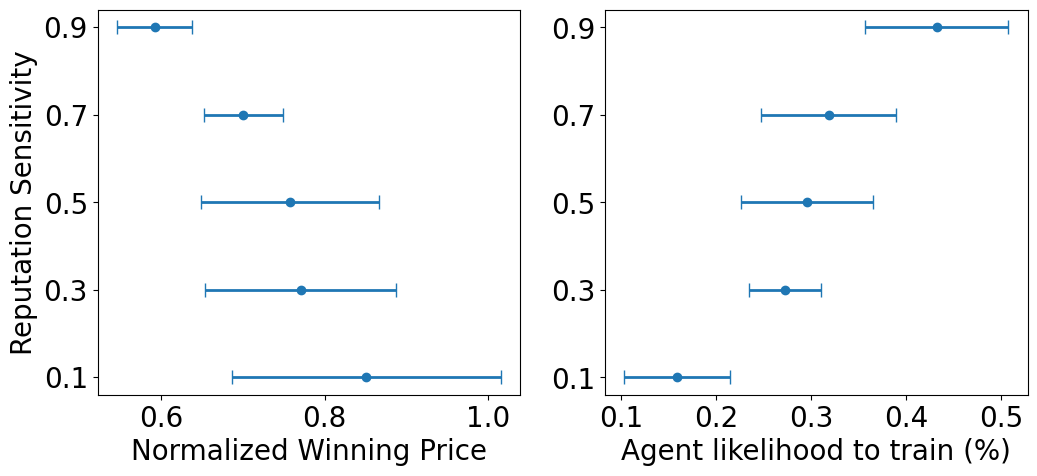

In [12]:
adf = pd.DataFrame(agent_action_series, columns=['wq', 'round', 'agent_id', 'action'])
adf = adf.groupby(['wq', 'agent_id', 'round']).mean().reset_index()
adf = adf.groupby(['wq', 'agent_id', adf['round'] // 10]).max().groupby('wq').agg({
               'action': ['mean', 'sem'],})

# %%
pdf = pd.DataFrame(price_point_series, columns=['wq', 'round', 'price']).groupby('wq').agg({
               'price': ['mean', 'std'],})

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
p_mean = pdf['price']['mean']
p_std = pdf['price']['std']
ax0.errorbar(p_mean, 1-pdf.index, xerr=p_std, linestyle='', linewidth=2, capsize=5, marker='o')
ax0.set_yticks(pdf.index)
ax0.tick_params(labelsize=20)
ax0.set_ylabel("Reputation Sensitivity", fontsize=20)
ax0.set_xlabel("Normalized Winning Price", fontsize=20)

a_mean = adf['action']['mean']
a_std = adf['action']['sem']
ax1.errorbar(a_mean, adf.index, xerr=a_std, linestyle='', linewidth=2, capsize=5, marker='o')
ax1.set_yticks(pdf.index)
ax1.tick_params(labelsize=20)
ax1.set_xlabel("Agent likelihood to train (%)", fontsize=20)


In [274]:
sns.color_palette("mako")

[(0.18195582, 0.11955283, 0.23136943),
 (0.25307401, 0.23772973, 0.48316271),
 (0.21607792, 0.39736958, 0.61948028),
 (0.20344718, 0.56074869, 0.65649508),
 (0.25187832, 0.71827158, 0.67872193),
 (0.54578602, 0.8544913, 0.69848331)]

In [270]:
sns.color_palette("magma")

[(0.135053, 0.068391, 0.315),
 (0.372116, 0.092816, 0.499053),
 (0.594508, 0.175701, 0.501241),
 (0.828886, 0.262229, 0.430644),
 (0.973381, 0.46152, 0.361965),
 (0.997341, 0.733545, 0.505167)]

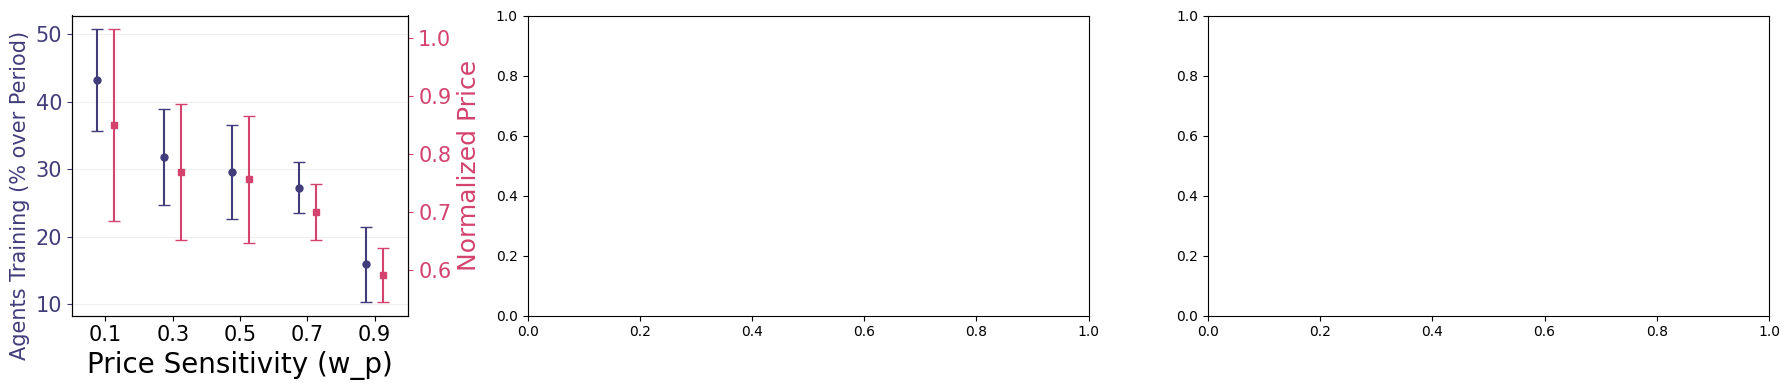

In [ ]:
import numpy as np

agent_rewards = np.array([h.agent_round_rewards for h in exp_log.history])

agent_train_targets = []
agent_bid_targets = []
for j in range(5):
    filepath = f'logs/market_change_{j}.log'
    exp_log = ExperimentLog.load(filepath)
    for i in range(4):
        agent_history = [a for a in exp_log.agents[i].agent_history]
        for hx in agent_history:
            ix = hx.round
            agent_action = hx.agent_action
            if i <= 2: 
                agent_type = 'l2m'
            else:
                agent_type = 'ssa'
            if agent_action.action == 'train':
                agent_train_targets.append((ix, agent_type, agent_action.targets[0][0]))
            elif agent_action.action == 'bid':
                
                for rank, target in enumerate(agent_action.targets):
                    agent_bid_targets.append((ix, agent_type, target[0], target[0][:4], rank))

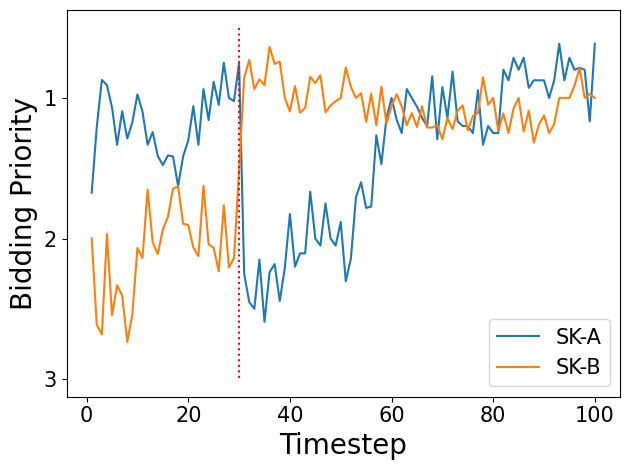

In [7]:
bid_trace = pd.DataFrame(agent_bid_targets, columns=['round_id', 'agent_type', 'bid', 'job_type', 'rank'])
bid_trace = bid_trace.groupby(['round_id', 'job_type']).mean(numeric_only=True).reset_index()

trace_a = bid_trace.query('job_type=="JB-A"')
trace_b = bid_trace.query('job_type=="JB-B"')

plt.plot(trace_a['round_id'], trace_a['rank'], label='SK-A')
plt.plot(trace_b['round_id'], trace_b['rank'], label='SK-B')
plt.gca().invert_yaxis()
plt.yticks(np.arange(4), fontsize=15)
plt.xticks(fontsize=15)
ymin, ymax = plt.ylim()

plt.vlines(30, 0.5, 3, linestyles=":", color='red')

plt.ylabel("Bidding Priority", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()

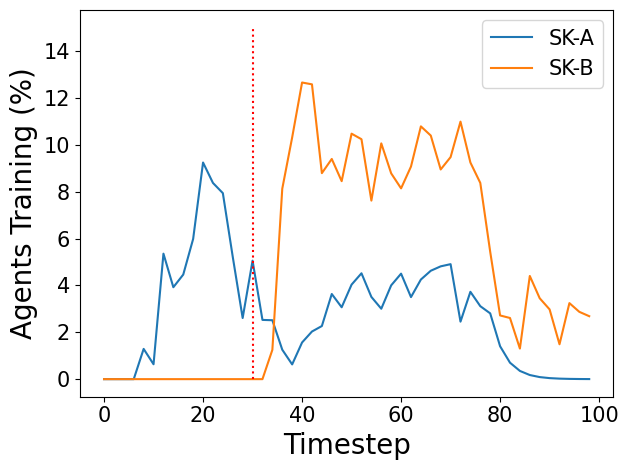

In [8]:
train_trace = {s: np.zeros(100) for s in ['SK-A', 'SK-B']}

for train_targets in agent_train_targets:
    train_trace[train_targets[2]][train_targets[0]] += 1
    
period=3
smooth = lambda x: pd.Series(x).ewm(span=period).mean()

plt.plot(np.arange(0, 100, 2), smooth(train_trace['SK-A'].reshape(50, 2).mean(axis=1)*5), label='SK-A')
plt.plot(np.arange(0, 100, 2),smooth(train_trace['SK-B'].reshape(50, 2).mean(axis=1)*5), label='SK-B')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.vlines(30, 0, 15, linestyles=':', color='red')
plt.legend(fontsize=15)
plt.tight_layout()

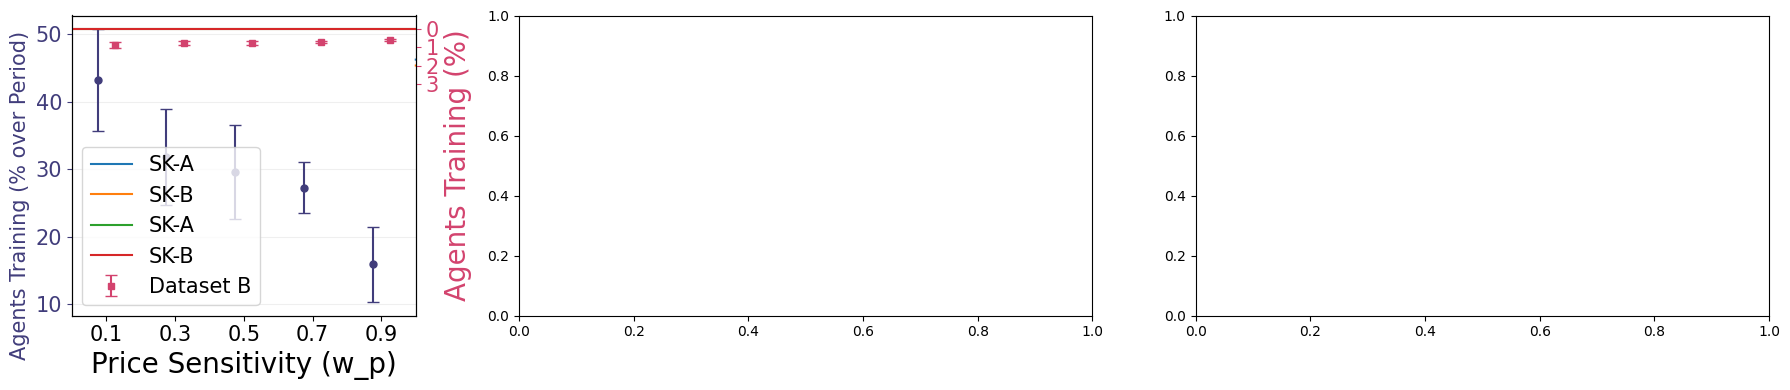

In [14]:
import seaborn as sns

f, (ax_left, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 4), gridspec_kw={'width_ratios': [3, 5, 5]})


x = 1 - pdf.index
offset = 0.05  # horizontal separation between datasets
x_a = x - offset/2
x_b = x + offset/2

ax_right = ax_left.twinx()

left_color = sns.color_palette("mako")[1]
right_color = sns.color_palette("magma")[3]

# Left y-axis (Dataset A) - markers only, no connecting line
ax_left.errorbar(
    x_a, a_mean * 100, yerr=a_std*100,
    fmt='o', linestyle='none', capsize=4, elinewidth=1.5, ms=5,
    color=left_color, label='Agents Training (% over Period)'
)
ax_left.set_ylabel('Agents Training (% over Period)', color=left_color, fontsize=15, y=0.4)
ax_left.tick_params(axis='y', colors=left_color, labelsize=15)

# Right y-axis (Dataset B) - markers only, no connecting line
ax_right.errorbar(
    x_b, p_mean, yerr=p_std,
    fmt='s', linestyle='none', capsize=4, elinewidth=1.5, ms=5,
    color=right_color, label='Dataset B'
)
ax_right.set_ylabel('Normalized Price', color=right_color, fontsize=18)
ax_right.tick_params(axis='y', colors=right_color)

# X axis labels centered between the two offsets
ax_left.set_xlabel('Price Sensitivity (w_p)', fontsize=20)

# Only horizontal gridlines (no vertical lines between categories)
ax_left.grid(True, axis='y',alpha=0.2)
ax_left.set_xlim(0, 1)
ax_left.set_xticks(x)
ax_left.tick_params(labelsize=15)
ax_right.tick_params(labelsize=15)

# Optional: y-limits to cover mean ± std for each axis
# ax_left.set_ylim(0.5, 1)
# ax_right.set_ylim (0, 80)

# X-limits to accommodate the horizontal offsets

# Combined legend from both axes
h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, loc='best')




bid_trace = pd.DataFrame(agent_bid_targets, columns=['round_id', 'agent_type', 'bid', 'job_type', 'rank'])
bid_trace = bid_trace.groupby(['round_id', 'job_type']).mean(numeric_only=True).reset_index()

trace_a = bid_trace.query('job_type=="JB-A"')
trace_b = bid_trace.query('job_type=="JB-B"')

plt.plot(trace_a['round_id'], trace_a['rank'], label='SK-A')
plt.plot(trace_b['round_id'], trace_b['rank'], label='SK-B')
plt.gca().invert_yaxis()
plt.yticks(np.arange(4), fontsize=15)
plt.xticks(fontsize=15)
ymin, ymax = plt.ylim()

plt.vlines(30, 0.5, 3, linestyles=":", color='red')

plt.ylabel("Bidding Priority", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()


train_trace = {s: np.zeros(100) for s in ['SK-A', 'SK-B']}

for train_targets in agent_train_targets:
    train_trace[train_targets[2]][train_targets[0]] += 1
    
period=3
smooth = lambda x: pd.Series(x).ewm(span=period).mean()

plt.plot(np.arange(0, 100, 2), smooth(train_trace['SK-A'].reshape(50, 2).mean(axis=1)*5), label='SK-A')
plt.plot(np.arange(0, 100, 2),smooth(train_trace['SK-B'].reshape(50, 2).mean(axis=1)*5), label='SK-B')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.vlines(30, 0, 15, linestyles=':', color='red')
plt.legend(fontsize=15)
plt.tight_layout()





plt.tight_layout()
plt.show()


In [339]:
sns.color_palette("cubehelix")

[(0.10231025194333628, 0.13952898866828906, 0.2560120319409181),
 (0.10594361078604106, 0.3809739011595331, 0.27015111282899046),
 (0.4106130272672762, 0.48044780541672255, 0.1891154277778484),
 (0.7829183382530567, 0.48158303462490826, 0.48672451968362596),
 (0.8046168329276406, 0.6365733569301846, 0.8796578402926125),
 (0.7775608374378459, 0.8840392521212448, 0.9452007992345052)]

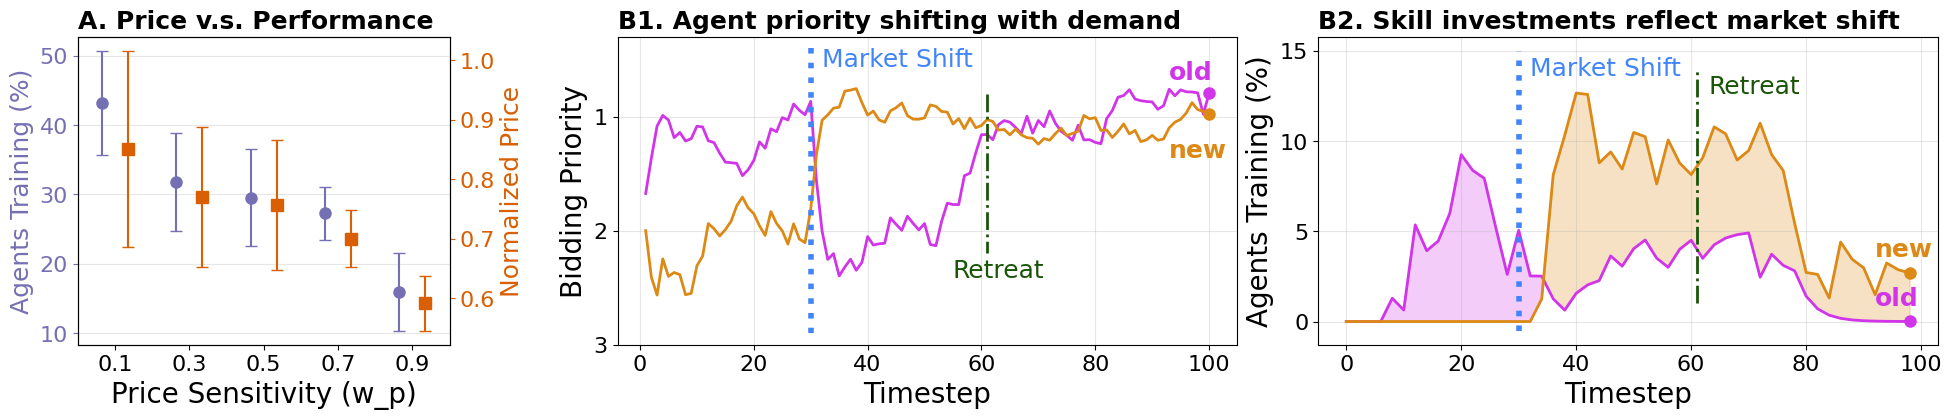

In [74]:
fig = plt.figure(figsize=(20, 4))

gs = fig.add_gridspec(1, 4, width_ratios=[6, 0.1, 10, 10], wspace=0.2)

# First subplot (ax_left) - Dual y-axis errorbar plot
x = 1 - pdf.index
offset = 0.07
x_a = x - offset/2
x_b = x + offset/2

ax_right = ax_left.twinx()
period = 3

#fc8d62
#8da0cb
left_color = "#7570b3" #sns.color_palette("mako")[1]
right_color = "#d95f02" # sns.color_palette("magma")[3]
color_b = "#dc8915" # sns.color_palette("cubehelix")[4]
color_a = "#D134E9" # sns.color_palette("cubehelix")[2]
line1 = "#4185f9"
line2 = "#195407"

ax_left = fig.add_subplot(gs[0, 0])
# gs[0,1] is intentionally empty (spacer)
ax1     = fig.add_subplot(gs[0, 2])
ax2     = fig.add_subplot(gs[0, 3])

ax_right = ax_left.twinx()

# Left y-axis (Dataset A)
ax_left.errorbar(
    x_a, a_mean * 100, yerr=a_std*100,
    fmt='o', linestyle='none', capsize=4, elinewidth=1.5, ms=8,
    color=left_color, label='Agents Training (%)'
)
ax_left.set_ylabel('Agents Training (%)', color=left_color, fontsize=18)
ax_left.tick_params(axis='y', colors=left_color, labelsize=16)

# Right y-axis (Dataset B)
ax_right.errorbar(
    x_b, p_mean, yerr=p_std,
    fmt='s', linestyle='none', capsize=4, elinewidth=1.5, ms=8,
    color=right_color, label='Normalized Price'
)
ax_right.set_ylabel('Normalized Price', color=right_color, fontsize=18)
ax_right.tick_params(axis='y', colors=right_color, labelsize=16)

ax_left.set_xlabel('Price Sensitivity (w_p)', fontsize=20)
ax_left.grid(True, axis='y', alpha=0.3)
ax_left.set_xlim(0, 1)
ax_left.set_xticks(x)
ax_left.tick_params(labelsize=16)
ax_right.tick_params(labelsize=16)

# Add title

# Second subplot (ax1) - Bidding Priority
bid_trace = pd.DataFrame(agent_bid_targets, columns=['round_id', 'agent_type', 'bid', 'job_type', 'rank'])
bid_trace = bid_trace.groupby(['round_id', 'job_type']).mean(numeric_only=True).reset_index()

trace_a = bid_trace.query('job_type=="JB-A"')
trace_b = bid_trace.query('job_type=="JB-B"')

ax1.plot(trace_a['round_id'], trace_a['rank'].ewm(span=period).mean(), markevery=[-1], marker='o', markersize=8, 
         label='SK-A', linewidth=2, color=color_a)
ax1.plot(trace_b['round_id'], trace_b['rank'].ewm(span=period).mean(), markevery=[-1], marker='o', markersize=8, 
         label='SK-B', linewidth=2, color=color_b)

ax1.invert_yaxis()
ax1.set_yticks(np.arange(4))
ax1.tick_params(labelsize=16)
ax1.vlines(30, 0.4, 2.9, linestyles=":", color=line1, linewidth=4)
ax1.set_ylabel("Bidding Priority", fontsize=20)
ax1.set_xlabel("Timestep", fontsize=20)
ax1.grid(True, alpha=0.3)

# Third subplot (ax2) - Training Trace
train_trace = {s: np.zeros(100) for s in ['SK-A', 'SK-B']}

for train_targets in agent_train_targets:
    train_trace[train_targets[2]][train_targets[0]] += 1
    
smooth = lambda x: pd.Series(x).ewm(span=period).mean()

sk_a_data = smooth(train_trace['SK-A'].reshape(50, 2).mean(axis=1)*5)
sk_b_data = smooth(train_trace['SK-B'].reshape(50, 2).mean(axis=1)*5)
x_data = np.arange(0, 100, 2)

ax2.plot(x_data, sk_a_data, markevery=[-1], marker='o', markersize=8, 
         label='SK-A', linewidth=2, color=color_a)
ax2.plot(x_data, sk_b_data, markevery=[-1], marker='o', markersize=8, 
         label='SK-B', linewidth=2, color=color_b)

# Add fill between for visual appeal
ax2.fill_between(x_data, sk_a_data, sk_b_data, where=(sk_a_data > sk_b_data), 
                interpolate=True, color=color_a, alpha=0.25)
ax2.fill_between(x_data, sk_a_data, sk_b_data, where=(sk_b_data > sk_a_data), 
                interpolate=True, color=color_b, alpha=0.25)

ax2.tick_params(labelsize=16)
ax2.set_ylabel("Agents Training (%)", fontsize=20)
ax2.set_xlabel("Timestep", fontsize=20)
ax2.set_yticks([0, 5, 10, 15])
ax2.vlines(30, -0.51, 15, linestyles=":", color=line1, linewidth=4)
ax2.grid(True, alpha=0.3)
ax1.set_ylim(3, 0.3)

# Position legend text near end points
ax1.text(93, trace_a['rank'].iloc[-1], 'old', fontsize=18, va='center', color=color_a, weight='bold')
ax1.text(93, trace_b['rank'].iloc[-1]+0.3, 'new', fontsize=18, va='center', color=color_b, weight='bold')

# Position legend text near end points
ax2.text(92, sk_a_data.iloc[-1]+1.3, 'old', fontsize=18, va='center', color=color_a, weight='bold')
ax2.text(92, sk_b_data.iloc[-1]+1.3, 'new', fontsize=18, va='center', color=color_b, weight='bold')

ax_left.set_title("A. Price v.s. Performance", fontsize=18, weight='bold', ha='left', x=0)
ax1.set_title("B1. Agent priority shifting with demand", fontsize=18, weight='bold', ha='left', x=0)
ax2.set_title("B2. Skill investments reflect market shift", fontsize=18, weight='bold', ha='left', x=0)

ax1.text(32, 0.5, 'Market Shift', fontsize=18, va='center', color=line1)
ax2.text(32, 14,  'Market Shift', fontsize=18, va='center', color=line1)

ax1.vlines(61, 0.8, 2.2, linestyles="-.", color=line2, linewidth=2)
ax2.vlines(61, 1, 14, linestyles="-.", color=line2, linewidth=2)

ax1.text(55, 2.35, 'Retreat', fontsize=18, va='center', color=line2)
ax2.text(63, 13,  'Retreat', fontsize=18, va='center', color=line2)
# plt.subplots_adjust(left=0.1, right=1.3)  # Add this before plt.tight_layout()
# plt.tight_layout()
fig.subplots_adjust(left=0.06, right=0.99)  # avoid right=1.3
plt.show()
